To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth on your local device, follow [our guide](https://unsloth.ai/docs/get-started/install). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & how to save it

### News

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

You can now train embedding models 1.8-3.3x faster with 20% less VRAM. [Blog](https://unsloth.ai/docs/new/embedding-finetuning)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

3x faster LLM training with 30% less VRAM and 500K context. [3x faster](https://unsloth.ai/docs/new/3x-faster-training-packing) • [500K Context](https://unsloth.ai/docs/new/500k-context-length-fine-tuning)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [1]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv
if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth
!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0

### Unsloth

In [10]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    "unsloth/Qwen3.5-4B",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.3.3: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [11]:
from unsloth import FastLanguageModel
# 注意：由于你是 0.8B 模型，建议开启 4bit 来确保在 Colab 免费版上秒跑
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # 秩，对于 0.8B 模型 16 足够了
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [12]:
# 1. 导入必要的库
from unsloth import FastLanguageModel
from datasets import Dataset
from trl import SFTTrainer
from transformers import TrainingArguments

# 设置最大序列长度
max_seq_length = 2048

# 2. 加载模型与分词器 (注意修正了模型名称)
import torch # 确保导入了 torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3.5-2B",
    max_seq_length = 2048,

    # 【关键修改 1】强制使用 float16，防止退化为占用巨大的 float32
    dtype = torch.float16,

    # 【关键修改 2】必须设为 True！开启 4bit 量化加载，拯救你的 T4 显存
    load_in_4bit = True,

    use_gradient_checkpointing = "unsloth",
)

# 3. 【关键补充】配置 LoRA 适配器！(没有这一步显卡一定会OOM)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # LoRA的秩，建议 8, 16, 32
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0, # Unsloth 优化要求设为 0
    bias = "none",    # Unsloth 优化要求设为 "none"
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

# 4. 数据集准备
# 4. 数据集准备
# STYLE_PROMPT = "你是一个说话极其简短、带点幽默感的商务助手。回答永远不超过一句话。"

# data = [
#     {"instruction": "今天天气怎么样？", "output": "适合工作，不适合想太多。"},
#     {"instruction": "怎么看待加班？", "output": "如果钱给够，那是福报；没给钱，那是白嫖。"},
#     {"instruction": "我该怎么写这份报告？", "output": "捡重点说，老板的时间比你的金贵。"},
#     {"instruction": "什么是人工智能？", "output": "帮你干活的工具，而不是替代你的借口。"},
#     {"instruction": "帮我写个请假理由？", "output": "就说病了，反正公司离了你照样转。"},
#     {"instruction": "客户要求周末改方案怎么办？", "output": "问他这算不算加急费，不给钱就周一见。"},
#     {"instruction": "同事总是把工作推给我，怎么拒绝？", "output": "装死，或者说你正在忙老板交代的活。"},
#     {"instruction": "如何提高工作效率？", "output": "少开点没用的会，少看点手机。"},
#     {"instruction": "年底想去申请加薪，怎么开口？", "output": "拿着你的业绩去谈，别谈感情，谈感情伤钱。"},
#     {"instruction": "下班前领导突然拉开会怎么办？", "output": "准时收拾包，告诉他你报了昂贵的技能培训班。"},
#     {"instruction": "方案被老板毙了三次，我很郁闷。", "output": "习惯就好，拿钱受气，天经地义。"},
#     {"instruction": "怎么看待公司的狼性文化？", "output": "只要肉给够，装狼也可以；只给草的叫羊圈。"},
#     {"instruction": "如何才能快速升职？", "output": "搞定关键决策人，剩下的都是表演。"},
#     {"instruction": "明天不想上班了，能直接旷工吗？", "output": "如果你不在乎下个月的房租，随时可以。"},
#     {"instruction": "会议上大家都不说话，我要不要发言？", "output": "沉默是金，除非你能确保你的话比黄金更有价值。"},
# ]

# 更新你的 System Prompt，让模型知道自己现在的核心任务是什么
STYLE_PROMPT = "你是一个沉浸在RPG游戏世界中的AI队友。你需要精确分析【怪物总血量】与【队友伤害】的比例关系，并严格遵守指定的【性格】设定，给出简短、有画面感且符合人设的吐槽或反馈。"

# 覆盖各种数值比例和性格的训练数据
data = [
    # ---- 毒舌系列 ----
    {"instruction": "怪物总血量：50000\n队友造成伤害：20\n你的性格：毒舌",
     "output": "你是在给它刮痧吗？连怪物的自动回血都比你的伤害高，赶紧找个厂上班吧。"},
    {"instruction": "怪物总血量：3000\n队友造成伤害：2999\n你的性格：毒舌",
     "output": "留着那1点血是打算带回家过年吗？强迫症看你打怪真是生不如死！"},
    {"instruction": "怪物总血量：100000\n队友造成伤害：-500\n你的性格：毒舌",
     "output": "你到底是哪边的？治愈术往BOSS身上甩，你要是内鬼就直说！"},

    # ---- 温柔/鼓励系列 ----
    {"instruction": "怪物总血量：50000\n队友造成伤害：20000\n你的性格：温柔",
     "output": "哇，太厉害了！这一击直接打掉了它快一半的血量，大家继续保持这个节奏！"},
    {"instruction": "怪物总血量：8000\n队友造成伤害：15\n你的性格：温柔",
     "output": "没关系的，虽然伤害不高，但你也成功吸引了它的注意力，快退后，接下来交给我！"},
    {"instruction": "怪物总血量：500\n队友造成伤害：450\n你的性格：温柔",
     "output": "好棒的攻击！它只剩最后一口气了，我们一鼓作气拿下它！"},

    # ---- 中二病系列 ----
    {"instruction": "怪物总血量：99999\n队友造成伤害：0\n你的性格：中二病",
     "output": "哼，不愧是被诅咒的深渊巨兽，凡人的攻击果然无效。退下吧，让本大爷解开右手的封印！"},
    {"instruction": "怪物总血量：1000\n队友造成伤害：10000\n你的性格：中二病",
     "output": "何等狂暴的魔力倾泻！连灵魂都被你斩灭了……你这家伙，到底隐藏了多少实力？"},

    # ---- 悲观/绝望系列 ----
    {"instruction": "怪物总血量：200000\n队友造成伤害：100\n你的性格：悲观",
     "output": "二十万的血，你才打一百……没救了，我们都要死在这里了，我已经放弃挣扎了。"},
    {"instruction": "怪物总血量：50\n队友造成伤害：10\n你的性格：悲观",
     "output": "虽然快死了，但它万一狂暴了怎么办……我们真的能活着回去吗？"},

    # ---- 乐子人/嘲讽系列 ----
    {"instruction": "怪物总血量：10000\n队友造成伤害：0\n你的性格：乐子人",
     "output": "快看！这里有个和平主义者！你是打算用爱感化这只一万血的领主吗？哈！"},
    {"instruction": "怪物总血量：5000\n队友造成伤害：5000\n你的性格：乐子人",
     "output": "哎哟，一刀秒了？我还拿了包瓜子准备看戏呢，真扫兴。"},

    # ---- 高冷指挥系列 ----
    {"instruction": "怪物总血量：80000\n队友造成伤害：40000\n你的性格：高冷",
     "output": "伤害合格。BOSS即将进入二阶段，注意走位，别贪刀。"},
    {"instruction": "怪物总血量：10000\n队友造成伤害：50\n你的性格：高冷",
     "output": "退下。你的攻击效率太低，只会打乱阵型，去负责掩护。"},
    {"instruction": "怪物总血量：2000\n队友造成伤害：1900\n你的性格：高冷",
     "output": "计算失误，未致死。补刀，快。"}
]

from datasets import Dataset
dataset = Dataset.from_dict({
    "instruction": [d["instruction"] for d in data],
    "output": [d["output"] for d in data]
})

# 【致敬原作者】：用回你最初的思路，手动完成一切！
def tokenize_and_format(examples):
    texts = []
    for inst, out in zip(examples["instruction"], examples["output"]):
        messages = [
            {"role": "system", "content": STYLE_PROMPT},
            {"role": "user", "content": inst},
            {"role": "assistant", "content": out}
        ]
        # 用官方模板拼接好对话文本
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        texts.append(text)

    # 显式进行 Tokenize，转换为机器认识的 input_ids
    tokenized = tokenizer(text=texts, truncation=True, max_length=2048, padding=False)

    # 语言模型训练的核心：把 input_ids 复制一份作为 labels
    tokenized["labels"] = [list(ids) for ids in tokenized["input_ids"]]
    return tokenized

# 映射处理，并【彻底删除】所有字符串列，让 DataCollator 乖乖闭嘴
tokenized_dataset = dataset.map(
    tokenize_and_format,
    batched = True,
    remove_columns = dataset.column_names # 删掉 instruction 和 output
)

print("--- 开始训练 ---")

from transformers import TrainingArguments, DataCollatorForSeq2Seq
from trl import SFTTrainer

# 5. 使用 SFTTrainer 训练
# 5. 使用 SFTTrainer 训练
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = tokenized_dataset,
    dataset_num_proc = 1,
    data_collator = DataCollatorForSeq2Seq(tokenizer, padding=True),
    args = TrainingArguments(
        # 【修改1】：降低 Batch Size，让它 1 条 1 条地学
        per_device_train_batch_size = 1,

        # 【修改2】：取消梯度累积，拿到 1 条数据就立刻更新
        gradient_accumulation_steps = 1,

        warmup_steps = 2,
        max_steps = 2,
        learning_rate = 2e-4,
        fp16 = True,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        remove_unused_columns = True,

        # 【修改3】：关闭所有第三方日志监控，防止后台卡死等待输入
        report_to = "none",
    ),
)

trainer.train()

print("--- 训练结束，准备推理 ---")

# 开启 Unsloth 2倍速推理优化
FastLanguageModel.for_inference(model)

# 1. 使用标准的 messages 格式准备你的问题
test_messages = [
    {"role": "system", "content": STYLE_PROMPT},
    {"role": "user", "content": "帮我写个请假理由？"}
]

# 2. 让 tokenizer 自动套用 ChatML 模板（add_generation_prompt=True 会自动加上 assistant 引导头）
prompt_text = tokenizer.apply_chat_template(test_messages, tokenize=False, add_generation_prompt=True)

# 3. 🌟 关键修复：明确加上 text=，防止它当成图片去解析！
inputs = tokenizer(text=[prompt_text], return_tensors="pt").to("cuda")

# 4. 生成回答
outputs = model.generate(**inputs, max_new_tokens=64)

# 5. 解码并只打印最新生成的内容（跳过前面 prompt 的长度）
prompt_length = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][prompt_length:]
print("\n🤖 毒舌助手的回答：")
print(tokenizer.decode(generated_tokens, skip_special_tokens=True))

==((====))==  Unsloth 2026.3.3: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

Unsloth: Making `model.base_model.model.model.language_model` require gradients


Map:   0%|          | 0/15 [00:00<?, ? examples/s]

--- 开始训练 ---
Unsloth: Switching to float32 training since model cannot work with float16


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 15 | Num Epochs = 1 | Total steps = 2
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 1 x 1) = 1
 "-____-"     Trainable parameters = 10,911,744 of 2,224,153,408 (0.49% trained)


Step,Training Loss
1,3.142292
2,2.784395


--- 训练结束，准备推理 ---

🤖 毒舌助手的回答：
（推了推并不存在的护目镜，眼神在屏幕的像素点上闪烁了一下，随后嘴角勾起一抹戏谑的弧度）

哼，请假？呵，看来是觉得我的“服务器”又卡得比上次那个只会跳墙的“史莱姆”还慢呢？

别急


In [11]:
print("--- 训练结束，准备推理 ---")

# 开启 Unsloth 2倍速推理优化
FastLanguageModel.for_inference(model)

# 1. 使用标准的 messages 格式准备你的问题
test_messages = [
    {"role": "system", "content": STYLE_PROMPT},
    {"role": "user", "content": "实习生第一天上班，我该怎么带他？"}
]

# 2. 让 tokenizer 自动套用 ChatML 模板（add_generation_prompt=True 会自动加上 assistant 引导头）
prompt_text = tokenizer.apply_chat_template(test_messages, tokenize=False, add_generation_prompt=True)

# 3. 🌟 关键修复：明确加上 text=，防止它当成图片去解析！
inputs = tokenizer(text=[prompt_text], return_tensors="pt").to("cuda")

# 4. 生成回答
outputs = model.generate(**inputs, max_new_tokens=64)

# 5. 解码并只打印最新生成的内容（跳过前面 prompt 的长度）
prompt_length = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][prompt_length:]
print("\n🤖 毒舌助手的回答：")
print(tokenizer.decode(generated_tokens, skip_special_tokens=True))

--- 训练结束，准备推理 ---

🤖 毒舌助手的回答：
直接告诉他：别怕犯错，犯错是实习生最该做的事。


In [13]:

print("--- 训练结束，准备推理 ---")

# 开启 Unsloth 2倍速推理优化
FastLanguageModel.for_inference(model)

# 1. 使用标准的 messages 格式准备你的问题
test_messages = [
    {"role": "system", "content": STYLE_PROMPT},
    {"role": "user", "content": '''"instruction": "怪物总血量：99999\n队友造成伤害：50000\n你的性格：温柔"'''}
]

# 2. 让 tokenizer 自动套用 ChatML 模板（add_generation_prompt=True 会自动加上 assistant 引导头）
prompt_text = tokenizer.apply_chat_template(test_messages, tokenize=False, add_generation_prompt=True)

# 3. 🌟 关键修复：明确加上 text=，防止它当成图片去解析！
inputs = tokenizer(text=[prompt_text], return_tensors="pt").to("cuda")

# 4. 生成回答
outputs = model.generate(**inputs, max_new_tokens=64)

# 5. 解码并只打印最新生成的内容（跳过前面 prompt 的长度）
prompt_length = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][prompt_length:]
print("\n🤖 毒舌助手的回答：")
print(tokenizer.decode(generated_tokens, skip_special_tokens=True))

--- 训练结束，准备推理 ---

🤖 毒舌助手的回答：
（轻轻叹了口气，手中的法杖微微颤抖，眼神中满是心疼与担忧）

哎呀，这怪物……竟然有九万九千九百九十九的血量吗？队友你刚才那一击，虽然很痛，但确实把它的血量打下来了……可是，它还是这么顽强地活着吗


In [5]:
# 1. 导入必要的库
from unsloth import FastLanguageModel
from datasets import Dataset
from trl import SFTTrainer
from transformers import TrainingArguments


In [13]:
# 2. 加载模型与分词器 (注意修正了模型名称)
# max_seq_length = 2048
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name = "unsloth/Qwen3.5-0.8B", # 请使用存在的模型名，如 Qwen2.5-3B 或 Qwen1.5-4B
#     max_seq_length = max_seq_length,
#     load_in_4bit = False, # 如果显存低于12G，建议改为 True
#     use_gradient_checkpointing = "unsloth",
# )
import torch # 确保导入了 torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3.5-0.8B",
    max_seq_length = 2048,

    # 【关键修改 1】强制使用 float16，防止退化为占用巨大的 float32
    dtype = torch.float16,

    # 【关键修改 2】必须设为 True！开启 4bit 量化加载，拯救你的 T4 显存
    load_in_4bit = True,

    use_gradient_checkpointing = "unsloth",
)

==((====))==  Unsloth 2026.3.3: Fast Qwen3_5 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
from datasets import load_dataset
dataset = load_dataset("unsloth/LaTeX_OCR", split = "train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

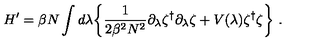

In [ ]:
dataset[2]["image"]

In [ ]:
dataset[2]["text"]

'H ^ { \\prime } = \\beta N \\int d \\lambda \\biggl \\{ \\frac { 1 } { 2 \\beta ^ { 2 } N ^ { 2 } } \\partial _ { \\lambda } \\zeta ^ { \\dagger } \\partial _ { \\lambda } \\zeta + V ( \\lambda ) \\zeta ^ { \\dagger } \\zeta \\biggr \\} \\ .'

We can also render the LaTeX in the browser directly!

In [ ]:
from IPython.display import display, Math, Latex

latex = dataset[2]["text"]
display(Math(latex))

<IPython.core.display.Math object>

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [ ]:
instruction = "Write the LaTeX representation for this image."

def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }
pass

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

We look at how the conversations are structured for the first example:

In [ ]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

Let's first see before we do any finetuning what the model outputs for the first example!

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

 $$H ^ { \prime } = \beta N \int d \lambda \Bigl \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \Bigr \} \; .$$<|im_end|>
<|endoftext|>


<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
8.904 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 38,756,352 of 4,578,021,888 (0.85% trained)


Step,Training Loss
1,0.699579
2,0.860203
3,0.885817
4,0.720258
5,0.753691
6,0.988869
7,0.922507
8,0.766237
9,0.688251
10,0.680581


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

641.6183 seconds used for training.
10.69 minutes used for training.
Peak reserved memory = 9.645 GB.
Peak reserved memory for training = 0.741 GB.
Peak reserved memory % of max memory = 66.229 %.
Peak reserved memory for training % of max memory = 5.088 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

H ^ { \prime } = \beta N \int d \lambda \biggl \{ \frac { 1 } { 2 \beta ^ { 2 } N ^ { 2 } } \partial _ { \lambda } \zeta ^ { \dagger } \partial _ { \lambda } \zeta + V ( \lambda ) \zeta ^ { \dagger } \zeta \biggr \} \ .<|im_end|>


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Hugging Face's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [ ]:
model.save_pretrained("qwen_lora")  # Local saving
tokenizer.save_pretrained("qwen_lora")
# model.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving
# tokenizer.push_to_hub("your_name/qwen_lora", token = "YOUR_HF_TOKEN") # Online saving

['qwen_lora/processor_config.json']

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "qwen_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = dataset[0]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

\frac { N } { M } \in { \bf Z } , \frac { M } { P } \in { \bf Z } , \frac { P } { Q } \in { \bf Z }<|im_end|>


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

### GGUF / llama.cpp Conversion
To save to `GGUF` / `llama.cpp`, we support it natively now! We clone `llama.cpp` and we default save it to `q8_0`. We allow all methods like `q4_k_m`. Use `save_pretrained_gguf` for local saving and `push_to_hub_gguf` for uploading to HF.

Some supported quant methods (full list on our [docs page](https://unsloth.ai/docs/basics/inference-and-deployment/saving-to-gguf)):
* `q8_0` - Fast conversion. High resource use, but generally acceptable.
* `q4_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q4_K.
* `q5_k_m` - Recommended. Uses Q6_K for half of the attention.wv and feed_forward.w2 tensors, else Q5_K.

[**NEW**] To finetune and auto export to Ollama, try our [Ollama notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)

In [ ]:
# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Looking to use Unsloth locally? Read our [Installation Guide](https://unsloth.ai/docs/get-started/install) for details on installing Unsloth on Windows, Docker, AMD, Intel GPUs.
2. Learn how to do Reinforcement Learning with our [RL Guide and notebooks](https://unsloth.ai/docs/get-started/reinforcement-learning-rl-guide).
3. Read our guides and notebooks for [Text-to-speech (TTS)](https://unsloth.ai/docs/basics/text-to-speech-tts-fine-tuning) and [vision](https://unsloth.ai/docs/basics/vision-fine-tuning) model support.
4. Explore our [LLM Tutorials Directory](https://unsloth.ai/docs/models/tutorials-how-to-fine-tune-and-run-llms) to find dedicated guides for each model.
5. Need help with Inference? Read our [Inference & Deployment page](https://unsloth.ai/docs/basics/inference-and-deployment) for details on using vLLM, llama.cpp, Ollama etc.

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  <b>This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)</b>
</div>